In [1]:
student_scores = [70, 71, 72, 72, 74, 75, 80, 81 , 85, 90, 95, 99]

In [2]:
import numpy as np
import pandas as pd

### Splitting the scores into bins

**cut** creates fixed-width bins

In [7]:
# define the bin edges
bins = list(range(70, 105, 5))
bins

[70, 75, 80, 85, 90, 95, 100]

In [8]:
# create the labeled ranges
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
labels

['70-75', '75-80', '80-85', '85-90', '90-95', '95-100']

In [9]:
# Bin the scores
score_ranges = pd.cut(student_scores, bins=bins, labels=labels, right=False)
score_ranges

['70-75', '70-75', '70-75', '70-75', '70-75', ..., '80-85', '85-90', '90-95', '95-100', '95-100']
Length: 12
Categories (6, object): ['70-75' < '75-80' < '80-85' < '85-90' < '90-95' < '95-100']

In [11]:
# Count frequencies
freq = score_ranges.value_counts().sort_index()
print(freq)

70-75     5
75-80     1
80-85     2
85-90     1
90-95     1
95-100    2
Name: count, dtype: int64


In [28]:
freq.values

array([5, 1, 2, 1, 1, 2])

In [29]:
df = pd.DataFrame({"score_range": freq.index, "frequency": freq.values})
df


,score_range,frequency
0,70-75,5
1,75-80,1
2,80-85,2
3,85-90,1
4,90-95,1
5,95-100,2


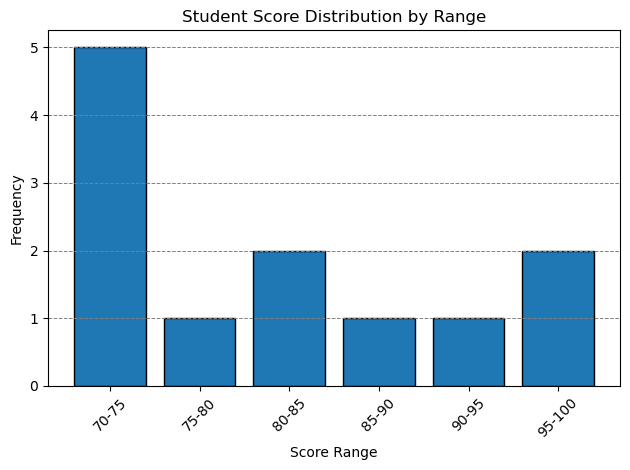

In [39]:
import matplotlib.pyplot as plt
plt.bar(df['score_range'], df['frequency'], edgecolor="black")
plt.grid(axis="y", color="gray", linestyle="--", linewidth=0.7)
plt.xlabel("Score Range")
plt.ylabel("Frequency")
plt.title("Student Score Distribution by Range")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
df['Density/P(x)'] = df['frequency']/ 60
df

,score_range,frequency,Density/P(x)
0,70-75,5,0.083333
1,75-80,1,0.016667
2,80-85,2,0.033333
3,85-90,1,0.016667
4,90-95,1,0.016667
5,95-100,2,0.033333


In [43]:
df['Area = w * P(x)'] = df['Density/P(x)'] * 5
df

,score_range,frequency,Density/P(x),Area = w * P(x)
0,70-75,5,0.083333,0.416667
1,75-80,1,0.016667,0.083333
2,80-85,2,0.033333,0.166667
3,85-90,1,0.016667,0.083333
4,90-95,1,0.016667,0.083333
5,95-100,2,0.033333,0.166667


In [44]:
df['midpoint'] = df['score_range'].str.split("-").apply(lambda x: (int(x[0]) + int(x[1])) / 2)
df

,score_range,frequency,Density/P(x),Area = w * P(x),midpoint
0,70-75,5,0.083333,0.416667,72.5
1,75-80,1,0.016667,0.083333,77.5
2,80-85,2,0.033333,0.166667,82.5
3,85-90,1,0.016667,0.083333,87.5
4,90-95,1,0.016667,0.083333,92.5
5,95-100,2,0.033333,0.166667,97.5


## How to create a smooth plot 
You have a few excellent ways to make your density line smooth and curvy instead of a straight, point‑to‑point polyline. The right choice depends on how smooth you want the curve to be and how much interpolation you’re comfortable with.
Below are the three most common and reliable approaches.

🌟 **Option 1: Use a spline (smoothest and most common)**

A spline interpolates between your midpoints and produces a smooth curve. (see code below)
This gives you a beautiful, smooth curve.

🌟 **Option 2: Use a rolling mean (gentle smoothing)**

If you want a softer smoothing without interpolation:
```
df["smooth"] = df["Density/P(x)"].rolling(window=3, center=True).mean()

plt.plot(df["midpoint"], df["smooth"], marker="o")
```

🌟 **Option 3: Use a lowess smoother (statistical smoothing)**
LOWESS is great for noisy data:
```
import statsmodels.api as sm

lowess = sm.nonparametric.lowess
smooth = lowess(df["Density/P(x)"], df["midpoint"], frac=0.4)

plt.plot(smooth[:,0], smooth[:,1])
```

🧠 **Which one should you choose?**

- Spline → smoothest, most visually appealing
- Rolling mean → simplest, no extra libraries
- LOWESS → best for noisy or irregular data

Given your score‑range density setup, cubic spline is usually the best match.


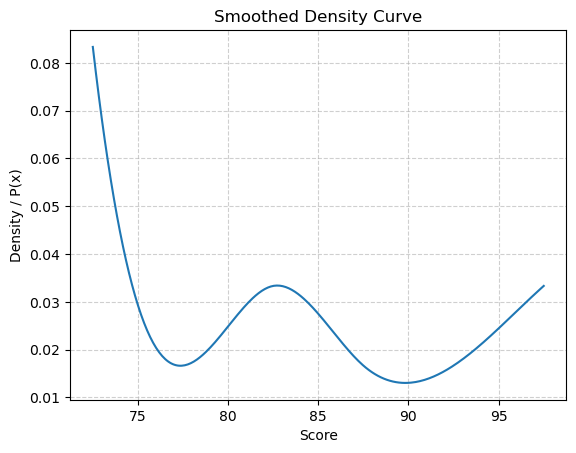

In [46]:
import numpy as np
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt

x = df["midpoint"].values
y = df["Density/P(x)"].values

# Create a smooth x-grid
x_smooth = np.linspace(x.min(), x.max(), 300)

# Build spline and evaluate it
spline = make_interp_spline(x, y, k=3)   # k=3 → cubic spline
y_smooth = spline(x_smooth)

plt.plot(x_smooth, y_smooth)
plt.xlabel("Score")
plt.ylabel("Density / P(x)")
plt.title("Smoothed Density Curve")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()